# Self-Organizing Maps (SOM)
##By Gabriel Velazquez

## Goal:

1. **Implement a SOM from scratch** (square and hexagonal grids) on a real problem — star classification — and learn to **read and interpret** its visualizations (U-Matrix, component planes, hit map, quality metrics).

> **The idea that runs through the whole notebook.** A SOM is, at once, three things: a **vector quantizer** (it summarizes many data points into a few prototypes), a **topology-preserving projection** (nearby data → nearby neurons), and a discrete approximation to a **principal manifold**. Every method we will see relaxes or tightens one of these three properties.

---

#### The problem: the Hertzsprung–Russell diagram

We use a dataset of **240 stars** described by 4 physical variables (temperature, luminosity, radius, absolute magnitude) and labeled into **6 types** (brown dwarf, red dwarf, white dwarf, main sequence, supergiant, hypergiant). The labels are **not** used to train the SOM (it is unsupervised); they are only used to *evaluate*, after the fact, whether the map reconstructed the known physics — the famous H–R diagram — without ever being taught it.

## Part 1 · Theoretical foundations of the SOM

### 1.1 What is it, and where does it come from?

A **Self-Organizing Map** (Teuvo Kohonen, 1982) is an **unsupervised** neural network inspired by the **retinotopic and tonotopic** organization of the cerebral cortex: neighboring regions of the cortex respond to similar stimuli. The SOM turns that idea into an algorithm: a fixed grid of neurons (usually 2D) that learns to **cover** the data distribution so that **neurons adjacent on the grid represent similar data**.

Unlike a feedforward network, here there are **no layers and no backpropagation**: each neuron $i$ is simply a **prototype vector** $\mathbf{w}_i \in \mathbb{R}^D$ that lives in the *same* space as the data, but also has a **fixed position** $\mathbf{r}_i \in \mathbb{R}^2$ on the grid. Learning is **competitive**: for each data point, one neuron "wins" and adjusts, dragging its grid neighbors along with it.

### 1.2 The algorithm in three steps

For each data point $\mathbf{x}$ presented at iteration $t$:

**1) Competition — Best Matching Unit (BMU).** We look for the neuron most similar to the data point in feature space:
$$ c(\mathbf{x}) = \arg\min_{i} \; \lVert \mathbf{x} - \mathbf{w}_i \rVert $$

**2) Cooperation — neighborhood.** Not only the winner is adjusted: a Gaussian **neighborhood function** centered on the BMU is defined, measured on the **grid** (not on the weights):
$$ h_{ci}(t) = \exp\!\left( -\frac{\lVert \mathbf{r}_c - \mathbf{r}_i \rVert^2}{2\,\sigma(t)^2} \right) $$
where $\sigma(t)$ is the neighborhood **radius**. This is the piece that distinguishes the SOM from plain K-Means: it couples the neurons spatially.

**3) Adaptation — weight update.** Each neuron moves toward the data point in proportion to its topological closeness to the BMU:
$$ \mathbf{w}_i(t+1) = \mathbf{w}_i(t) + \alpha(t)\, h_{ci}(t)\, \big(\mathbf{x} - \mathbf{w}_i(t)\big) $$
with $\alpha(t)$ the **learning rate**.

### 1.3 The two decaying parameters, and the two phases

Both $\alpha(t)$ and $\sigma(t)$ **decrease** over time (typically exponentially: $\sigma(t)=\sigma_0 e^{-t/\tau}$). This produces two qualitatively different phases:

| Phase | Radius $\sigma$ | What happens |
|---|---|---|
| **Ordering** (start) | large | The map "unfolds" and **untangles**; the global topology is set. |
| **Convergence** (end) | small | Local fine-tuning; each neuron refines its prototype almost like K-Means. |

> **Why the order matters.** If we started with a small $\sigma$, the map would never unfold: it would stay twisted (high *topographic error*). The large initial radius is what guarantees **topology preservation**.

### 1.4 What does a SOM optimize? (the honest subtlety)

A well-known theoretical limitation: **the SOM in its original form does not minimize a well-defined global cost function** (Erwin et al., 1992). It is a stochastic descent process with no exact energy in the continuous case. This motivated alternatives with an explicit probabilistic foundation — in particular **GTM**, which we will see in Part 5 as "the SOM done right" from a statistical standpoint. Even so, in practice the SOM converges to excellent configurations and is much cheaper than its generative cousins.

### 1.5 Loading the data and normalization

We load the dataset and apply **Min-Max normalization** to $[0,1]$. Normalization is **critical** for a SOM: the BMU is decided by Euclidean distance, so without normalizing, *temperature* (thousands of K) would completely dominate *radius* (tens), and the map would only "see" one variable.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.patches import RegularPolygon
import math
try:
    from IPython.display import display
except Exception:
    display = print

URL = 'https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Stars.csv'
try:
    df = pd.read_csv(URL)
except Exception as e:
    raise RuntimeError(
        "Could not download the dataset. On Colab this should work as long as internet access is enabled. "
        "Alternative: upload 'Stars.csv' and use pd.read_csv('Stars.csv'). Detail: " + str(e))

X_raw = df[['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)']].values
y_true = df['Star type'].values
class_names = ['Brown Dwarf', 'Red Dwarf', 'White Dwarf', 'Main Sequence', 'Supergiant', 'Hypergiant']
star_colors = ['#8B4513', '#FF0000', '#00E5FF', '#FFFF00', '#FFA500', '#9C27B0']

# Min-Max normalization -> [0, 1]
X_norm = (X_raw - X_raw.min(axis=0)) / (X_raw.max(axis=0) - X_raw.min(axis=0))

# Common network configuration
rows, cols = 12, 12
input_dim = 4
num_iterations = 5000

print(f"Dataset: {df.shape[0]} stars, {input_dim} variables, {len(class_names)} types.")
print("Class distribution:", dict(zip(*np.unique(y_true, return_counts=True))))

Dataset: 240 stars, 4 variables, 6 types.
Class distribution: {np.int64(0): np.int64(40), np.int64(1): np.int64(40), np.int64(2): np.int64(40), np.int64(3): np.int64(40), np.int64(4): np.int64(40), np.int64(5): np.int64(40)}


### 1.6 Mini-EDA: the H–R diagram the SOM will have to rediscover

Before training, it is worth *seeing* the structure we expect the map to capture. On the **Temperature vs. Luminosity** plane (log scale, as astronomers do), the 6 classes occupy well-differentiated regions: that is the **Hertzsprung–Russell diagram**. Our hypothesis: an unsupervised SOM should reorganize its neurons into a geography that reproduces these regions.

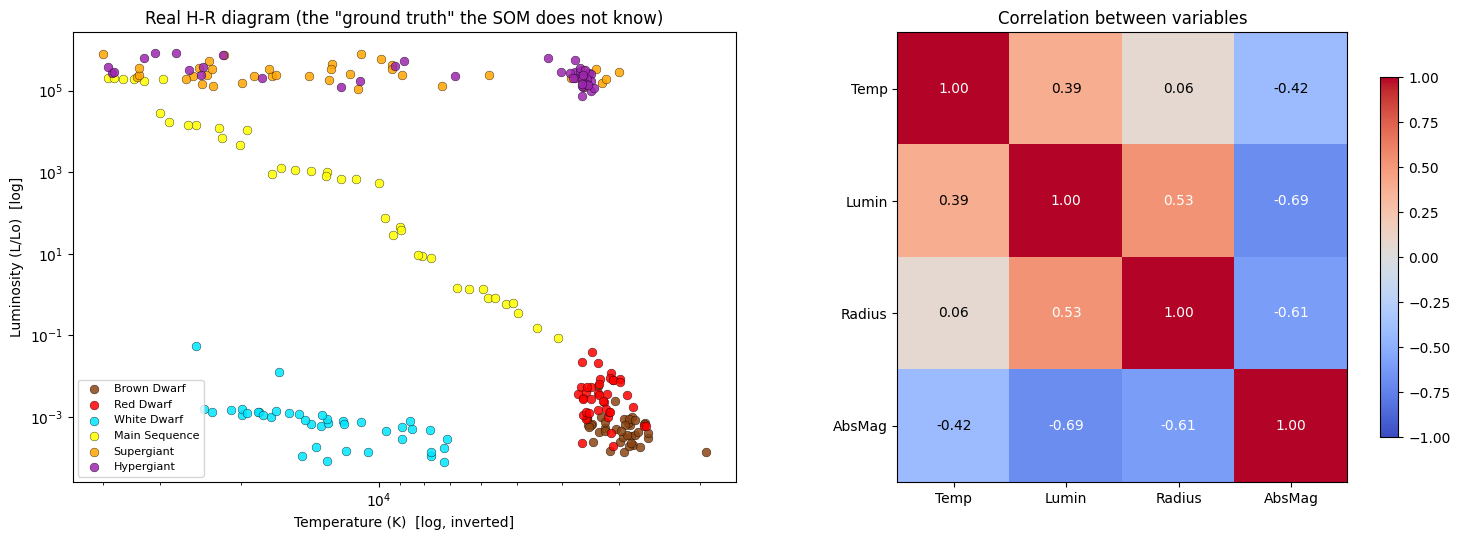

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Classic H-R diagram (inverted temperature, log axes)
ax = axes[0]
for t in range(6):
    m = y_true == t
    ax.scatter(X_raw[m, 0], X_raw[m, 1], s=40, c=star_colors[t],
               edgecolors='k', linewidths=0.3, label=class_names[t], alpha=0.85)
ax.set_xscale('log'); ax.set_yscale('log')
ax.invert_xaxis()  # astronomical convention: temperature decreases to the right
ax.set_xlabel('Temperature (K)  [log, inverted]'); ax.set_ylabel('Luminosity (L/Lo)  [log]')
ax.set_title('Real H-R diagram (the "ground truth" the SOM does not know)')
ax.legend(fontsize=8, loc='lower left')

# (b) Correlation matrix of the 4 normalized variables
ax = axes[1]
corr = np.corrcoef(X_norm.T)
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
labs = ['Temp', 'Lumin', 'Radius', 'AbsMag']
ax.set_xticks(range(4)); ax.set_xticklabels(labs); ax.set_yticks(range(4)); ax.set_yticklabels(labs)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr[i,j])>0.5 else 'black')
ax.set_title('Correlation between variables')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## Part 2 · From-scratch implementation: square vs. hexagonal grid

### 2.1 Why two geometries?

The **grid topology** determines how many immediate neighbors each neuron has, and therefore how cooperation propagates:

- **Square**: 4 neighbors (von Neumann) or 8 (Moore). Easy to index, but introduces **anisotropy**: the distance to a diagonal neighbor ($\sqrt2$) differs from the orthogonal one ($1$).
- **Hexagonal**: 6 **equidistant** neighbors. It is the geometry **recommended by Kohonen** because neighborhoods are isotropic and the resulting maps are visually more faithful. We implement it with a trigonometric projection: odd rows are shifted by $0.5$ and the height is scaled by $\sqrt3/2$.

We will train **both** with the same data and hyperparameters so we can compare them. We include an **audit block** that prints, on the first iteration, the entire computation (BMU, distances, $\alpha$, $\sigma$, the update applied) so the process is transparent instead of a "black box."

--- STARTING SQUARE-GRID TRAINING ---

SQUARE AUDIT - ITERATION 1
Star under analysis: Red Dwarf (index 131)
  4D input vector: [4.380e-02 0.000e+00 2.000e-04 6.961e-01]
  Winning BMU: Row 0, Column 1
  Minimum Euclidean distance: 0.2631
  BMU's previous weights: [0.156  0.156  0.0581 0.8662]
  Dynamic parameters: alpha = 0.5000 | sigma = 6.0000
  Update applied to the BMU: [-0.0561 -0.078  -0.0289 -0.0851]
  BMU's new weights: [0.0999 0.078  0.0291 0.7811]
... processing remaining iterations ...



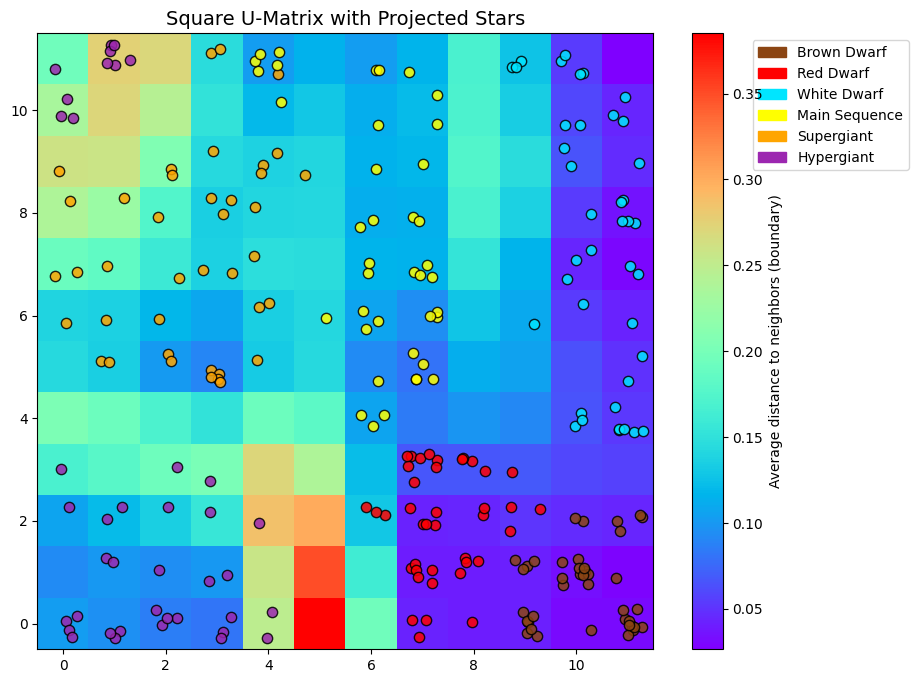

In [ ]:
np.random.seed(42)
square_weights = np.random.rand(rows, cols, input_dim)

initial_lr = 0.5
initial_radius = max(rows, cols) / 2
time_constant = num_iterations / np.log(initial_radius)

num_inspections = 1  # how many iterations get printed for the numerical audit

print("--- STARTING SQUARE-GRID TRAINING ---")
for t in range(num_iterations):
    random_idx = np.random.randint(len(X_norm))
    sample = X_norm[random_idx]
    true_type = class_names[y_true[random_idx]]

    # 1. BMU (Best Matching Unit)
    bmu_dist = np.linalg.norm(square_weights - sample, axis=2)
    bmu = np.unravel_index(np.argmin(bmu_dist), bmu_dist.shape)

    current_radius = initial_radius * np.exp(-t / time_constant)
    current_lr = initial_lr * np.exp(-t / time_constant)

    # 2. Neighborhood on the rectangular grid
    gx, gy = np.indices((rows, cols))
    grid_dist = (gx - bmu[0])**2 + (gy - bmu[1])**2
    influence = np.exp(-grid_dist / (2 * (current_radius**2)))

    # --- NUMERICAL AUDIT (initial iteration) ---
    if t < num_inspections:
        print(f"\n{'='*50}\nSQUARE AUDIT - ITERATION {t+1}\n{'='*50}")
        print(f"Star under analysis: {true_type} (index {random_idx})")
        print(f"  4D input vector: {np.round(sample, 4)}")
        print(f"  Winning BMU: Row {bmu[0]}, Column {bmu[1]}")
        print(f"  Minimum Euclidean distance: {bmu_dist[bmu]:.4f}")
        print(f"  BMU's previous weights: {np.round(square_weights[bmu[0], bmu[1]], 4)}")
        print(f"  Dynamic parameters: alpha = {current_lr:.4f} | sigma = {current_radius:.4f}")
        delta = current_lr * influence[bmu[0], bmu[1]] * (sample - square_weights[bmu[0], bmu[1]])
        print(f"  Update applied to the BMU: {np.round(delta, 4)}")

    # 3. Weight update
    square_weights += current_lr * np.expand_dims(influence, axis=2) * (sample - square_weights)

    if t < num_inspections:
        print(f"  BMU's new weights: {np.round(square_weights[bmu[0], bmu[1]], 4)}")
        print(f"{'='*50}\n... processing remaining iterations ...\n")

# 4. Square U-Matrix (8-neighborhood)
umatrix_square = np.zeros((rows, cols))
for i in range(rows):
    for j in range(cols):
        distances = []
        for di in [-1, 0, 1]:
            for dj in [-1, 0, 1]:
                if di == 0 and dj == 0: continue
                ni, nj = i + di, j + dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    distances.append(np.linalg.norm(square_weights[i, j] - square_weights[ni, nj]))
        umatrix_square[i, j] = np.mean(distances)

# 5. Render the square U-Matrix with projected stars
plt.figure(figsize=(10, 8))
plt.title("Square U-Matrix with Projected Stars", fontsize=14)
plt.imshow(umatrix_square, cmap='rainbow', interpolation='nearest', origin='lower')
plt.colorbar(label='Average distance to neighbors (boundary)')
np.random.seed(0)
for idx, sample in enumerate(X_norm):
    sub_dist = np.linalg.norm(square_weights - sample, axis=2)
    sub_bmu = np.unravel_index(np.argmin(sub_dist), sub_dist.shape)
    star_type = y_true[idx]
    jx, jy = np.random.uniform(-0.3, 0.3, 2)
    plt.scatter(sub_bmu[1] + jx, sub_bmu[0] + jy, c=star_colors[star_type],
                edgecolors='black', s=55, alpha=0.85, zorder=3)
legend_patches = [mpatches.Patch(color=star_colors[i], label=class_names[i]) for i in range(6)]
plt.legend(handles=legend_patches, bbox_to_anchor=(1.15, 1), loc='upper left')
plt.grid(False); plt.show()

--- STARTING HEXAGONAL-GRID TRAINING ---

HEXAGONAL AUDIT - ITERATION 1
Star: Red Dwarf (index 131)
  4D vector: [4.380e-02 0.000e+00 2.000e-04 6.961e-01]
  Grid BMU: Row 0, Column 1
  Geometric location on the plane: X = 1.000, Y = 0.000
  Parameters: alpha = 0.5000 | sigma = 6.0000


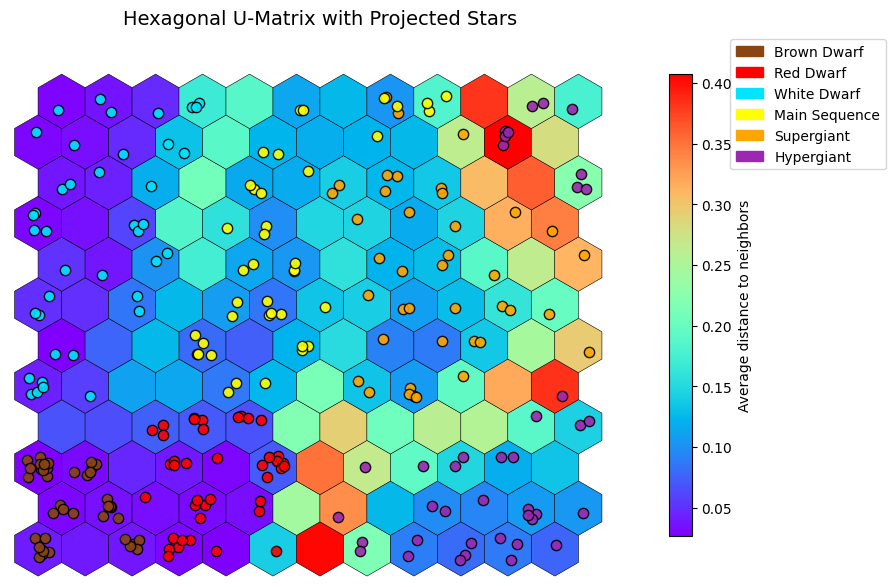

In [ ]:
# 1. Trigonometric projection of the hexagonal grid to Cartesian coordinates
coords_xy = np.zeros((rows, cols, 2))
for r in range(rows):
    for c in range(cols):
        coords_xy[r, c, 0] = c + 0.5 * (r % 2)          # odd rows shifted
        coords_xy[r, c, 1] = r * (math.sqrt(3) / 2)     # honeycomb cartesian height

np.random.seed(42)
hex_weights = np.random.rand(rows, cols, input_dim)

print("--- STARTING HEXAGONAL-GRID TRAINING ---")
for t in range(num_iterations):
    random_idx = np.random.randint(len(X_norm))
    sample = X_norm[random_idx]
    true_type = class_names[y_true[random_idx]]

    weight_dist = np.linalg.norm(hex_weights - sample, axis=2)
    bmu_idx = np.unravel_index(np.argmin(weight_dist), weight_dist.shape)
    bmu_x, bmu_y = coords_xy[bmu_idx[0], bmu_idx[1]]

    current_radius = max(0.1, initial_radius * math.exp(-t / time_constant))
    current_lr = initial_lr * math.exp(-t / time_constant)

    if t < num_inspections:
        print(f"\n{'='*50}\nHEXAGONAL AUDIT - ITERATION {t+1}\n{'='*50}")
        print(f"Star: {true_type} (index {random_idx})")
        print(f"  4D vector: {np.round(sample, 4)}")
        print(f"  Grid BMU: Row {bmu_idx[0]}, Column {bmu_idx[1]}")
        print(f"  Geometric location on the plane: X = {bmu_x:.3f}, Y = {bmu_y:.3f}")
        print(f"  Parameters: alpha = {current_lr:.4f} | sigma = {current_radius:.4f}")

    # Update based on real spatial distances on the honeycomb
    for r in range(rows):
        for c in range(cols):
            x_i, y_i = coords_xy[r, c]
            spatial_dist = math.hypot(bmu_x - x_i, bmu_y - y_i)
            if spatial_dist <= current_radius:
                influence = math.exp(-(spatial_dist**2) / (2 * (current_radius**2)))
                hex_weights[r, c] += current_lr * influence * (sample - hex_weights[r, c])

# Hexagonal U-Matrix (only the 6 immediate neighbors, filtered by distance <= 1.1)
umatrix_hex = np.zeros((rows, cols))
for r in range(rows):
    for c in range(cols):
        x_c, y_c = coords_xy[r, c]
        distances = []
        for r_n in range(max(0, r-1), min(rows, r+2)):
            for c_n in range(max(0, c-1), min(cols, c+2)):
                if r_n == r and c_n == c: continue
                if math.hypot(x_c - coords_xy[r_n, c_n, 0], y_c - coords_xy[r_n, c_n, 1]) <= 1.1:
                    distances.append(np.linalg.norm(hex_weights[r, c] - hex_weights[r_n, c_n]))
        if distances: umatrix_hex[r, c] = np.mean(distances)

# Hexagonal render
fig, ax = plt.subplots(figsize=(10, 10)); ax.set_aspect('equal')
plt.title("Hexagonal U-Matrix with Projected Stars", fontsize=14)
u_min, u_max = umatrix_hex.min(), umatrix_hex.max()
u_norm = (umatrix_hex - u_min) / (u_max - u_min)
cmap = cm.rainbow
for r in range(rows):
    for c in range(cols):
        x, y = coords_xy[r, c]
        ax.add_patch(RegularPolygon((x, y), numVertices=6, radius=0.58, orientation=0,
                                    facecolor=cmap(u_norm[r, c]), edgecolor='black', linewidth=0.4, zorder=1))
np.random.seed(0)
for idx, sample in enumerate(X_norm):
    sub_dist = np.linalg.norm(hex_weights - sample, axis=2)
    sub_bmu = np.unravel_index(np.argmin(sub_dist), sub_dist.shape)
    center_x, center_y = coords_xy[sub_bmu[0], sub_bmu[1]]
    jx, jy = np.random.uniform(-0.25, 0.25, 2)
    plt.scatter(center_x + jx, center_y + jy, c=star_colors[y_true[idx]],
                edgecolors='black', s=55, alpha=0.9, zorder=3)
ax.set_xlim(-0.6, cols + 0.6); ax.set_ylim(-0.6, rows * (math.sqrt(3)/2) + 0.6); plt.axis('off')
sm = cm.ScalarMappable(cmap=cmap); sm.set_array([u_min, u_max])
plt.colorbar(sm, ax=ax, label='Average distance to neighbors', shrink=0.6)
plt.legend(handles=legend_patches, bbox_to_anchor=(1.15, 1), loc='upper left'); plt.show()

## Part 3 · How to interpret a SOM

This is the heart of the presentation: a trained SOM **is not the goal**, it is a reading instrument. Here are the four lenses for interpreting it.

### 3.1 The U-Matrix (Unified Distance Matrix) — the "relief map"

Each cell is colored by the **average distance between that neuron's prototype and its grid neighbors' prototypes**. It is read like a **topographic map**:

- **Valleys** (cool colors, small distances) = very similar neurons → **one cluster**, dense.
- **Ridges** (warm colors, large distances) = **boundaries** between clusters: zones where prototypes change sharply.

> Reading trick: trace the warm-colored "walls" with your eye; whatever is enclosed is a natural group. In our stars, sharp boundaries should appear, separating, for example, the giants (high luminosity) from the dwarfs.

### 3.2 Component planes — per-variable "X-rays"

The U-Matrix says *where* the boundaries are, but not *why*. **Component planes** reveal that: the map is drawn **once per variable**, coloring each neuron by the value of **that** coordinate of its prototype. Comparing planes reveals the map's **semantics** (e.g., "the top-right corner = hot, luminous stars") and uncovers **correlations**: if two planes look alike, those variables are correlated.

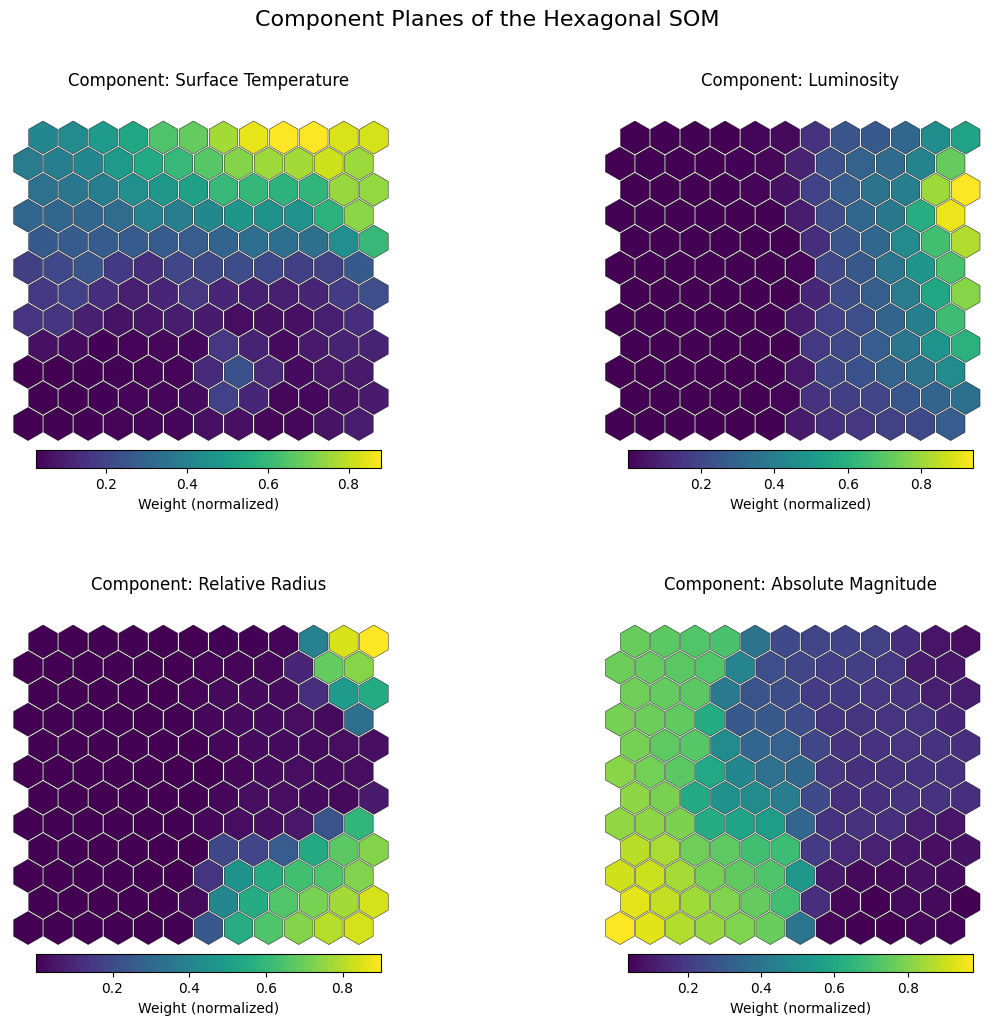

In [ ]:
# Component planes of the hexagonal SOM
features = ['Surface Temperature', 'Luminosity', 'Relative Radius', 'Absolute Magnitude']
fig, axes = plt.subplots(2, 2, figsize=(14, 12)); axes = axes.ravel()
plt.suptitle("Component Planes of the Hexagonal SOM", fontsize=16, y=0.95)
for d in range(input_dim):
    axes[d].set_aspect('equal'); axes[d].set_title(f"Component: {features[d]}", fontsize=12)
    comp = hex_weights[:, :, d]; cmin, cmax = comp.min(), comp.max()
    for r in range(rows):
        for c in range(cols):
            x, y = coords_xy[r, c]
            v = (comp[r, c] - cmin) / (cmax - cmin) if cmax > cmin else 0
            axes[d].add_patch(RegularPolygon((x, y), numVertices=6, radius=0.55, orientation=0,
                                             facecolor=cm.viridis(v), edgecolor='black', linewidth=0.3))
    axes[d].set_xlim(-0.6, cols + 0.6); axes[d].set_ylim(-0.6, rows * (math.sqrt(3)/2) + 0.6); axes[d].axis('off')
    sm_c = cm.ScalarMappable(cmap=cm.viridis); sm_c.set_array([cmin, cmax])
    plt.colorbar(sm_c, ax=axes[d], orientation='horizontal', pad=0.02, shrink=0.7, label='Weight (normalized)')
plt.show()

### 3.3 Hit map — usage density

Does the map use all of its neurons, or do the data "pile up" in just a few? The **hit map** counts how many data points have each neuron as their BMU. **Dead** neurons (0 hits) indicate an oversized map; very high concentrations indicate dense regions of the distribution. It also reveals the **magnification principle**: the SOM devotes more neurons to regions of the space where there is more data.

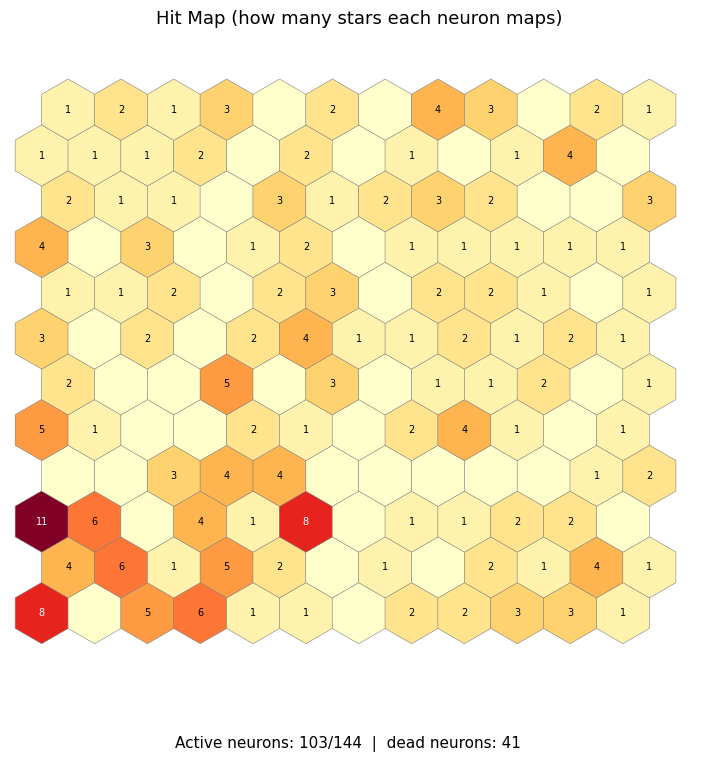

In [ ]:
# Hit map: BMU frequency per neuron
hits = np.zeros((rows, cols), dtype=int)
for sample in X_norm:
    d = np.linalg.norm(hex_weights - sample, axis=2)
    b = np.unravel_index(np.argmin(d), d.shape); hits[b] += 1

fig, ax = plt.subplots(figsize=(9, 9)); ax.set_aspect('equal')
plt.title("Hit Map (how many stars each neuron maps)", fontsize=13)
hmax = hits.max()
for r in range(rows):
    for c in range(cols):
        x, y = coords_xy[r, c]
        frac = hits[r, c] / hmax if hmax else 0
        ax.add_patch(RegularPolygon((x, y), numVertices=6, radius=0.58, orientation=0,
                                    facecolor=cm.YlOrRd(frac), edgecolor='gray', linewidth=0.4))
        if hits[r, c] > 0:
            ax.text(x, y, str(hits[r, c]), ha='center', va='center', fontsize=7,
                    color='black' if frac < 0.6 else 'white')
dead = int(np.sum(hits == 0))
ax.set_xlim(-0.6, cols + 0.6); ax.set_ylim(-0.6, rows * (math.sqrt(3)/2) + 0.6); ax.axis('off')
plt.figtext(0.5, 0.04, f"Active neurons: {rows*cols - dead}/{rows*cols}  |  dead neurons: {dead}",
            ha='center', fontsize=11)
plt.show()

### 3.4 Quality metrics: is this a good map?

Two numbers summarize the **two tensions** of a SOM:

**Quantization error (QE)** — fidelity. Average distance from each data point to its BMU:
$$ \mathrm{QE} = \frac{1}{N}\sum_{n} \lVert \mathbf{x}_n - \mathbf{w}_{c(\mathbf{x}_n)} \rVert $$
Low QE ⇒ the prototypes represent the data well. It grows if there are too few neurons.

**Topographic error (TE)** — topology preservation. Fraction of data points whose **first** and **second** BMU are **not neighbors** on the grid:
$$ \mathrm{TE} = \frac{1}{N}\sum_{n} \mathbb{1}\big[\,\text{BMU1}(\mathbf{x}_n)\ \text{and}\ \text{BMU2}(\mathbf{x}_n)\ \text{not adjacent}\big] $$
Low TE ⇒ the map is not "twisted"; smooth transitions.

> **The fundamental trade-off.** More neurons ⇒ QE drops but TE tends to rise (easier to twist). Fewer neurons ⇒ TE drops but QE rises. A good map balances both. That is why in Part 4 we search for hyperparameters that minimize a combination of the two.

In [ ]:
def compute_quality_metrics(norm_data, som_weights, coords_xy):
    total = len(norm_data); qe_sum = 0.0; breaks = 0
    for x in norm_data:
        dist = np.linalg.norm(som_weights - x, axis=2)
        order = np.argsort(dist, axis=None)
        bmu1 = np.unravel_index(order[0], dist.shape)
        bmu2 = np.unravel_index(order[1], dist.shape)
        qe_sum += dist[bmu1]
        x1, y1 = coords_xy[bmu1[0], bmu1[1]]
        x2, y2 = coords_xy[bmu2[0], bmu2[1]]
        if math.hypot(x1 - x2, y1 - y2) > 1.1:   # immediate honeycomb neighbors: dist <= 1.1
            breaks += 1
    return qe_sum / total, breaks / total

qe_hex, te_hex = compute_quality_metrics(X_norm, hex_weights, coords_xy)
print("=" * 45)
print("TOPOLOGICAL QUALITY REPORT")
print("=" * 45)
print(f"Quantization Error (QE): {qe_hex:.4f}")
print(f"  -> On average, each star is {qe_hex:.4f} away from its prototype (in normalized space).")
print(f"Topographic Error (TE): {te_hex:.4f}")
print(f"  -> {te_hex:.2%} of the data falls on neurons that break the map's continuity.")
print("=" * 45)

TOPOLOGICAL QUALITY REPORT
Quantization Error (QE): 0.0408
  -> On average, each star is 0.0408 away from its prototype (in normalized space).
Topographic Error (TE): 0.0875
  -> 8.75% of the data falls on neurons that break the map's continuity.


### 3.5 Two-level clustering: K-Means on the SOM prototypes

The U-Matrix suggests boundaries *by eye*; to get **explicit clusters** we apply a classic technique (Vesanto & Alhoniemi, 2000): **cluster the neurons, not the data**. Since the SOM already reduced 240 stars to 144 smoothed, ordered prototypes, running **K-Means on those 144 vectors** is fast, stable, and less noisy than clustering the raw data. The SOM acts as a **pre-processor that denoises and reduces**. This is also our first explicit point of contact with **K-Means**, which we will study in depth in Part 5.

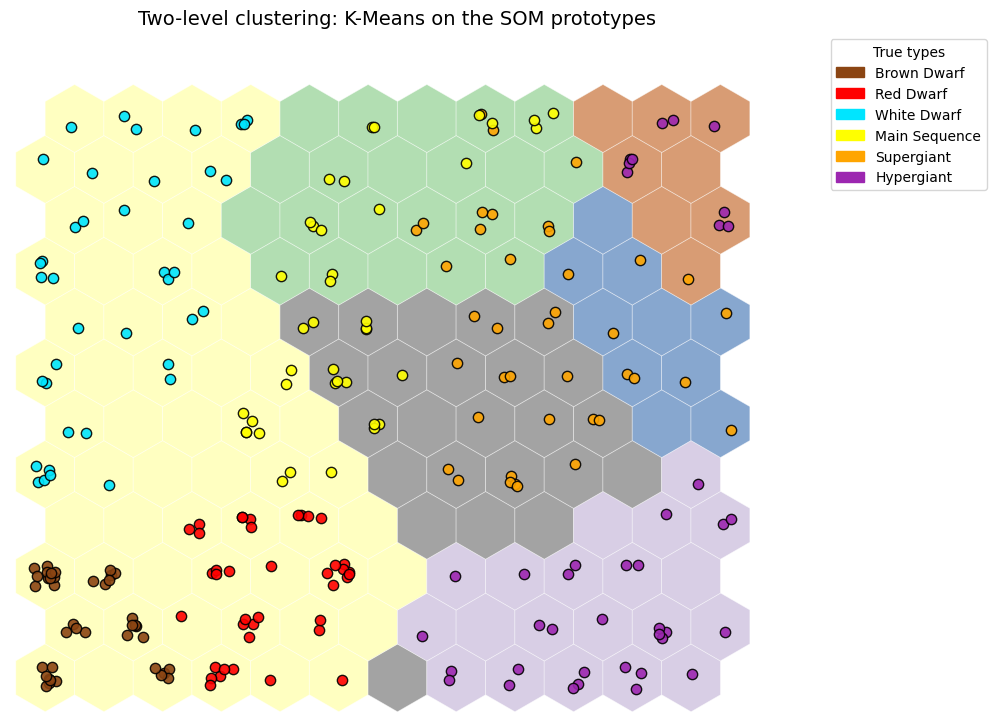

Background colors = clusters discovered by K-Means (unlabeled).
Points = true types. If they line up, the SOM reconstructed stellar physics in an unsupervised way.


In [ ]:
from sklearn.cluster import KMeans

flattened_weights = hex_weights.reshape(-1, input_dim)   # (144, 4): each neuron = one sample
som_kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_map = som_kmeans.fit_predict(flattened_weights).reshape(rows, cols)

fig, ax = plt.subplots(figsize=(10, 10)); ax.set_aspect('equal')
plt.title("Two-level clustering: K-Means on the SOM prototypes", fontsize=14)
discrete_cmap = plt.get_cmap('Accent', 6)
for r in range(rows):
    for c in range(cols):
        x, y = coords_xy[r, c]
        ax.add_patch(RegularPolygon((x, y), numVertices=6, radius=0.58, orientation=0,
                                    facecolor=discrete_cmap(cluster_map[r, c]),
                                    edgecolor='white', linewidth=0.6, alpha=0.6, zorder=1))
np.random.seed(0)
for idx, sample in enumerate(X_norm):
    d = np.linalg.norm(hex_weights - sample, axis=2); b = np.unravel_index(np.argmin(d), d.shape)
    x_c, y_c = coords_xy[b[0], b[1]]; jx, jy = np.random.uniform(-0.2, 0.2, 2)
    plt.scatter(x_c + jx, y_c + jy, c=star_colors[y_true[idx]],
                edgecolors='black', s=55, alpha=0.9, zorder=3)
ax.set_xlim(-0.6, cols + 0.6); ax.set_ylim(-0.6, rows * (math.sqrt(3)/2) + 0.6); plt.axis('off')
plt.legend(handles=[mpatches.Patch(color=star_colors[i], label=class_names[i]) for i in range(6)],
           bbox_to_anchor=(1.05, 1), loc='upper left', title="True types")
plt.show()
print("Background colors = clusters discovered by K-Means (unlabeled).")
print("Points = true types. If they line up, the SOM reconstructed stellar physics in an unsupervised way.")

## Part 4 · SOM hyperparameter tuning

We search for the **architecture** (grid size) and **number of iterations** that best balance QE and TE. We define a *score* that penalizes both, giving slightly more weight to TE (a twisted map is useless to interpret):
$$ \text{score} = \mathrm{QE} + 1.5\cdot\mathrm{TE} $$
This is an unsupervised **grid search**: unlike supervised tuning, there is no accuracy here; "quality" is purely geometric.

In [ ]:
import time
print("="*60); print("SOM HYPERPARAMETER TUNING (GRID SEARCH)"); print("="*60)

architectures = [(8, 8), (10, 10), (12, 12), (15, 15)]
iterations_grid = [2000, 5000]

def global_score(qe, te): return qe + te * 1.5

tuning_results = []; best_score = float('inf'); best_config = {}
for r_t, c_t in architectures:
    for it_t in iterations_grid:
        t0 = time.time()
        coords_t = np.zeros((r_t, c_t, 2))
        for r in range(r_t):
            for c in range(c_t):
                coords_t[r, c, 0] = c + 0.5 * (r % 2); coords_t[r, c, 1] = r * (math.sqrt(3) / 2)
        np.random.seed(42); weights_t = np.random.rand(r_t, c_t, input_dim)
        radius0 = max(r_t, c_t) / 2.0; tau = it_t / math.log(radius0)
        for t in range(it_t):
            sample = X_norm[np.random.randint(len(X_norm))]
            d = np.linalg.norm(weights_t - sample, axis=2); bmu = np.unravel_index(np.argmin(d), d.shape)
            xb, yb = coords_t[bmu[0], bmu[1]]
            ra = max(0.1, radius0 * math.exp(-t / tau)); ta = 0.5 * math.exp(-t / tau)
            for r in range(r_t):
                for c in range(c_t):
                    ds = math.hypot(xb - coords_t[r, c, 0], yb - coords_t[r, c, 1])
                    if ds <= ra:
                        weights_t[r, c] += ta * math.exp(-(ds**2) / (2 * ra**2)) * (sample - weights_t[r, c])
        qe_t, te_t = compute_quality_metrics(X_norm, weights_t, coords_t)
        sc = global_score(qe_t, te_t)
        tuning_results.append({'Grid': f"{r_t}x{c_t}", 'Iterations': it_t, 'QE': round(qe_t, 4),
                                  'TE': round(te_t, 4), 'Score': round(sc, 4), 'Time (s)': round(time.time()-t0, 2)})
        print(f"  {r_t}x{c_t}, {it_t} iter -> QE: {qe_t:.4f} | TE: {te_t:.4f} | score: {sc:.4f}")
        if sc < best_score: best_score = sc; best_config = tuning_results[-1]

tuning_df = pd.DataFrame(tuning_results).sort_values('Score').reset_index(drop=True)
print("\n" + "="*60); print("RESULT"); print("="*60)
display(tuning_df)
print(f"\nBest architecture: {best_config['Grid']} with {best_config['Iterations']} iterations "
      f"(score {best_config['Score']}).")

SOM HYPERPARAMETER TUNING (GRID SEARCH)
  8x8, 2000 iter -> QE: 0.0689 | TE: 0.0792 | score: 0.1876


  8x8, 5000 iter -> QE: 0.0679 | TE: 0.0250 | score: 0.1054


  10x10, 2000 iter -> QE: 0.0523 | TE: 0.1125 | score: 0.2210


  10x10, 5000 iter -> QE: 0.0497 | TE: 0.1125 | score: 0.2184


  12x12, 2000 iter -> QE: 0.0453 | TE: 0.0375 | score: 0.1015


  12x12, 5000 iter -> QE: 0.0408 | TE: 0.0875 | score: 0.1720


  15x15, 2000 iter -> QE: 0.0374 | TE: 0.1667 | score: 0.2874


  15x15, 5000 iter -> QE: 0.0335 | TE: 0.0958 | score: 0.1773

RESULT


,Grid,Iterations,QE,TE,Score,Time (s)
0,12x12,2000,0.0453,0.0375,0.1015,0.32
1,8x8,5000,0.0679,0.0250,0.1054,0.42
2,12x12,5000,0.0408,0.0875,0.1720,0.78
3,15x15,5000,0.0335,0.0958,0.1773,1.10
4,8x8,2000,0.0689,0.0792,0.1876,0.16
5,10x10,5000,0.0497,0.1125,0.2184,0.59
6,10x10,2000,0.0523,0.1125,0.2210,0.23
7,15x15,2000,0.0374,0.1667,0.2874,0.52



Best architecture: 12x12 with 2000 iterations (score 0.1015).


--- TRAINING OPTIMAL CONFIGURATION (12x12 | 2000 it) ---


Training completed successfully!
Generating visualizations...


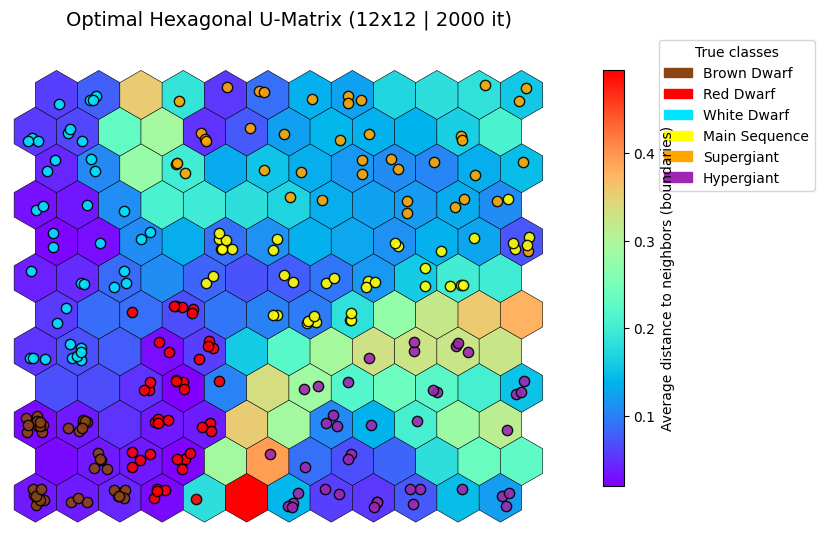

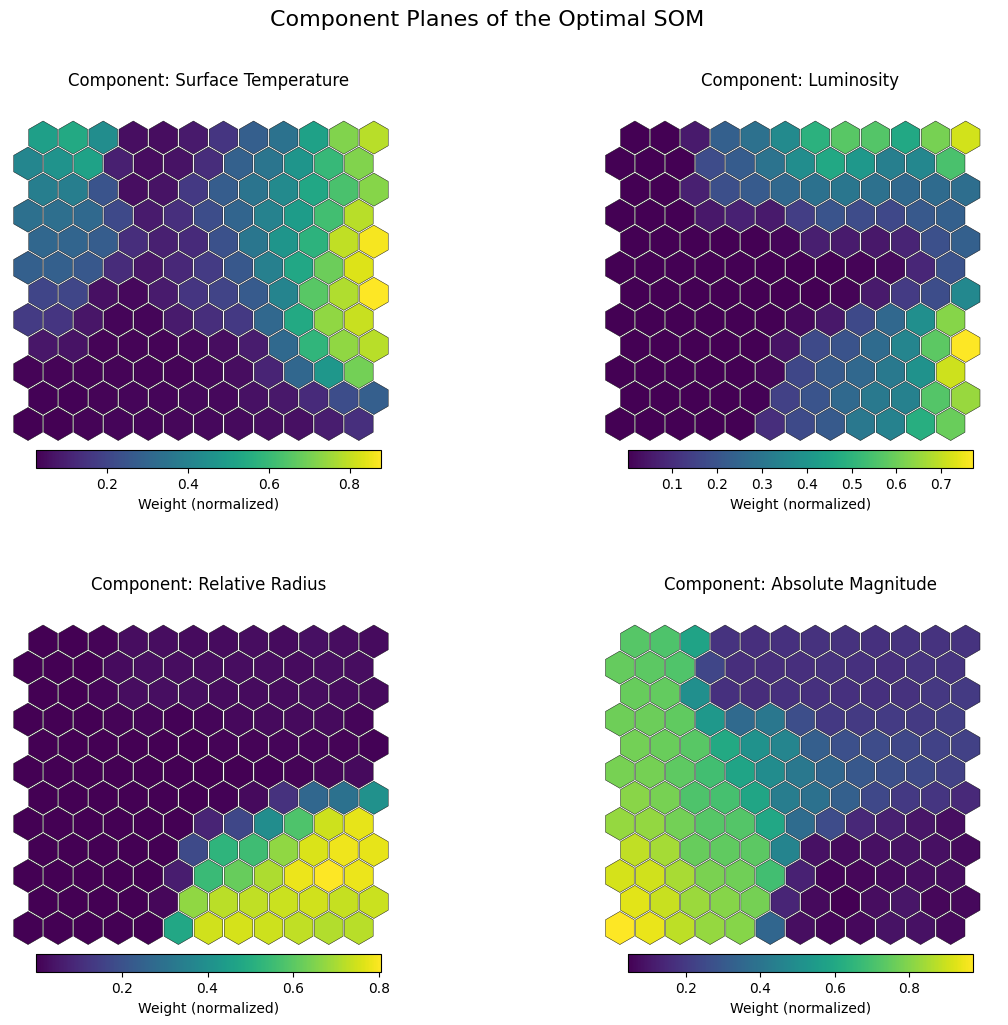

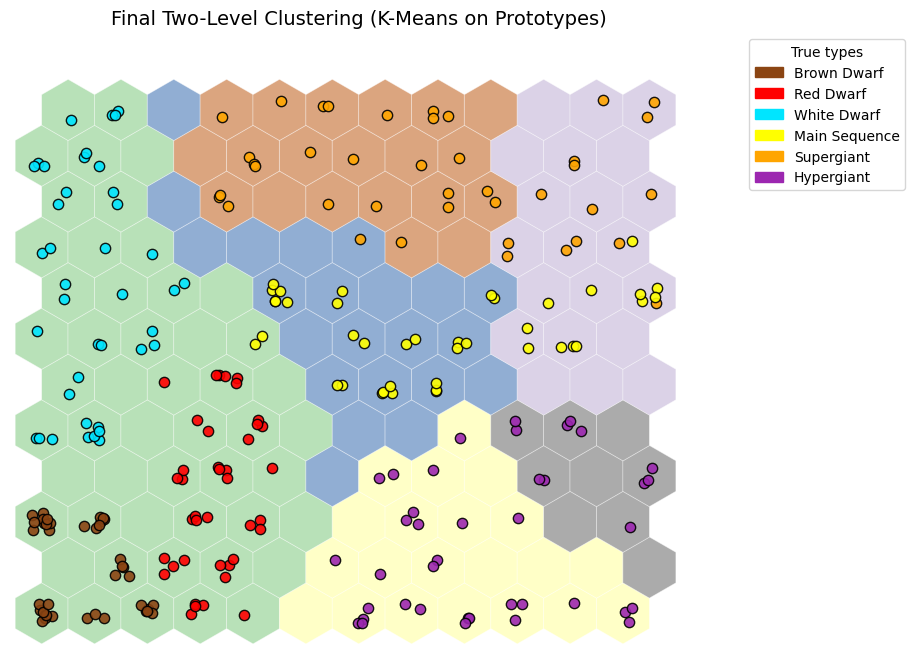

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.patches import RegularPolygon
import math
from sklearn.cluster import KMeans

# 1. CONFIGURATION OPTIMIZED BY THE GRID SEARCH
rows, cols = 12, 12
num_iterations = 2000
input_dim = 4

initial_lr = 0.5
initial_radius = max(rows, cols) / 2
time_constant = num_iterations / np.log(initial_radius)

class_names = ['Brown Dwarf', 'Red Dwarf', 'White Dwarf', 'Main Sequence', 'Supergiant', 'Hypergiant']
star_colors = ['#8B4513', '#FF0000', '#00E5FF', '#FFFF00', '#FFA500', '#9C27B0']
legend_patches = [mpatches.Patch(color=star_colors[i], label=class_names[i]) for i in range(6)]

# 2. PROJECT THE HEXAGONAL GRID
coords_xy = np.zeros((rows, cols, 2))
for r in range(rows):
    for c in range(cols):
        coords_xy[r, c, 0] = c + 0.5 * (r % 2)
        coords_xy[r, c, 1] = r * (math.sqrt(3) / 2)

# 3. TRAINING THE OPTIMIZED HEXAGONAL SOM
np.random.seed(42)
hex_weights = np.random.rand(rows, cols, input_dim)

print(f"--- TRAINING OPTIMAL CONFIGURATION ({rows}x{cols} | {num_iterations} it) ---")
for t in range(num_iterations):
    random_idx = np.random.randint(len(X_norm))
    sample = X_norm[random_idx]

    weight_dist = np.linalg.norm(hex_weights - sample, axis=2)
    bmu_idx = np.unravel_index(np.argmin(weight_dist), weight_dist.shape)
    bmu_x, bmu_y = coords_xy[bmu_idx[0], bmu_idx[1]]

    current_radius = max(0.1, initial_radius * math.exp(-t / time_constant))
    current_lr = initial_lr * math.exp(-t / time_constant)

    for r in range(rows):
        for c in range(cols):
            x_i, y_i = coords_xy[r, c]
            spatial_dist = math.hypot(bmu_x - x_i, bmu_y - y_i)
            if spatial_dist <= current_radius:
                influence = math.exp(-(spatial_dist**2) / (2 * (current_radius**2)))
                hex_weights[r, c] += current_lr * influence * (sample - hex_weights[r, c])

print("Training completed successfully!\nGenerating visualizations...")
# PLOT 1: FINAL HEXAGONAL U-MATRIX
umatrix_hex = np.zeros((rows, cols))
for r in range(rows):
    for c in range(cols):
        x_c, y_c = coords_xy[r, c]
        distances = []
        for r_n in range(max(0, r-1), min(rows, r+2)):
            for c_n in range(max(0, c-1), min(cols, c+2)):
                if r_n == r and c_n == c: continue
                if math.hypot(x_c - coords_xy[r_n, c_n, 0], y_c - coords_xy[r_n, c_n, 1]) <= 1.1:
                    distances.append(np.linalg.norm(hex_weights[r, c] - hex_weights[r_n, c_n]))
        if distances: umatrix_hex[r, c] = np.mean(distances)

fig, ax = plt.subplots(figsize=(9, 9)); ax.set_aspect('equal')
plt.title(f"Optimal Hexagonal U-Matrix ({rows}x{cols} | {num_iterations} it)", fontsize=14)
u_min, u_max = umatrix_hex.min(), umatrix_hex.max()
u_norm = (umatrix_hex - u_min) / (u_max - u_min) if u_max > u_min else umatrix_hex
cmap = cm.rainbow

for r in range(rows):
    for c in range(cols):
        x, y = coords_xy[r, c]
        ax.add_patch(RegularPolygon((x, y), numVertices=6, radius=0.58, orientation=0,
                                    facecolor=cmap(u_norm[r, c]), edgecolor='black', linewidth=0.4, zorder=1))

np.random.seed(0)
for idx, sample in enumerate(X_norm):
    sub_dist = np.linalg.norm(hex_weights - sample, axis=2)
    sub_bmu = np.unravel_index(np.argmin(sub_dist), sub_dist.shape)
    center_x, center_y = coords_xy[sub_bmu[0], sub_bmu[1]]
    jx, jy = np.random.uniform(-0.23, 0.23, 2)
    plt.scatter(center_x + jx, center_y + jy, c=star_colors[y_true[idx]],
                edgecolors='black', s=55, alpha=0.9, zorder=3)

ax.set_xlim(-0.6, cols + 0.6); ax.set_ylim(-0.6, rows * (math.sqrt(3)/2) + 0.6); plt.axis('off')
sm = cm.ScalarMappable(cmap=cmap); sm.set_array([u_min, u_max])
plt.colorbar(sm, ax=ax, label='Average distance to neighbors (boundaries)', shrink=0.6)
plt.legend(handles=legend_patches, bbox_to_anchor=(1.15, 1), loc='upper left', title="True classes")
plt.show()
# PLOT 2: OPTIMIZED COMPONENT PLANES
features = ['Surface Temperature', 'Luminosity', 'Relative Radius', 'Absolute Magnitude']
fig, axes = plt.subplots(2, 2, figsize=(14, 12)); axes = axes.ravel()
plt.suptitle("Component Planes of the Optimal SOM", fontsize=16, y=0.95)

for d in range(input_dim):
    axes[d].set_aspect('equal'); axes[d].set_title(f"Component: {features[d]}", fontsize=12)
    comp = hex_weights[:, :, d]; cmin, cmax = comp.min(), comp.max()
    for r in range(rows):
        for c in range(cols):
            x, y = coords_xy[r, c]
            v = (comp[r, c] - cmin) / (cmax - cmin) if cmax > cmin else 0
            axes[d].add_patch(RegularPolygon((x, y), numVertices=6, radius=0.55, orientation=0,
                                             facecolor=cm.viridis(v), edgecolor='black', linewidth=0.3))
    axes[d].set_xlim(-0.6, cols + 0.6); axes[d].set_ylim(-0.6, rows * (math.sqrt(3)/2) + 0.6); axes[d].axis('off')
    sm_c = cm.ScalarMappable(cmap=cm.viridis); sm_c.set_array([cmin, cmax])
    plt.colorbar(sm_c, ax=axes[d], orientation='horizontal', pad=0.02, shrink=0.7, label='Weight (normalized)')
plt.show()
# PLOT 3: FINAL TWO-LEVEL CLUSTERING (SOM + K-MEANS)
flattened_weights = hex_weights.reshape(-1, input_dim)
som_kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_map = som_kmeans.fit_predict(flattened_weights).reshape(rows, cols)

fig, ax = plt.subplots(figsize=(9, 9)); ax.set_aspect('equal')
plt.title("Final Two-Level Clustering (K-Means on Prototypes)", fontsize=14)
discrete_cmap = plt.get_cmap('Accent', 6)

for r in range(rows):
    for c in range(cols):
        x, y = coords_xy[r, c]
        ax.add_patch(RegularPolygon((x, y), numVertices=6, radius=0.58, orientation=0,
                                    facecolor=discrete_cmap(cluster_map[r, c]),
                                    edgecolor='white', linewidth=0.6, alpha=0.55, zorder=1))

np.random.seed(0)
for idx, sample in enumerate(X_norm):
    d = np.linalg.norm(hex_weights - sample, axis=2); b = np.unravel_index(np.argmin(d), d.shape)
    x_c, y_c = coords_xy[b[0], b[1]]; jx, jy = np.random.uniform(-0.2, 0.2, 2)
    plt.scatter(x_c + jx, y_c + jy, c=star_colors[y_true[idx]],
                edgecolors='black', s=55, alpha=0.9, zorder=3)

ax.set_xlim(-0.6, cols + 0.6); ax.set_ylim(-0.6, rows * (math.sqrt(3)/2) + 0.6); plt.axis('off')
plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="True types")
plt.show()